<h1> Geometric Operations and Other Mathematical Tools</h1>


Estimated time needed: **40** minutes


<h2>Objectives</h2>


In the first part of the lab, you will apply geometric transformations to an image. This allows you to perform different operations like reshape translation i.e. to shift, reshape and rotate the image. In the second part of the lab, you will learn how to apply some basic array and matrix operations to the image. 


<ul>
    <li><a href='#PT'> Geometric Operations  </a>
        <ul>
            <li>Scaling  </li>
            <li>Translation</li>
            <li>Rotation</li>   
          </ul>
        <li><a href='#PT'>  Mathematical Operations   </a>
        <ul>
            <li>Array Operations  </li>
            <li>Matix Operations n</li> 
          </ul>


</ul>


----


Download the image for the lab:


In [ ]:
# Tải các file ảnh từ internet
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png -O lenna.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png -O baboon.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png -O barbara.png  

--2026-01-30 13:49:36--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 473831 (463K) [image/png]
Saving to: ‘lenna.png’

lenna.png           100%[===================>] 462.73K  73.9KB/s    in 6.3s    

2026-01-30 13:49:43 (73.9 KB/s) - ‘lenna.png’ saved [473831/473831]

--2026-01-30 13:49:44--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-cours

We will import the following:


In [ ]:
# Import các thư viện 
import matplotlib.pyplot as plt
import cv2
import numpy as np

First, let's define a helper function to plot two images side-by-side. You will not need to understand this code this moment, but this function will be used repeatedly in this tutorial to showcase the results. 


In [ ]:
# Định nghĩa hàm để vẽ 2 ảnh cạnh nhau đễ dễ so sánh
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    # Tạo figure với kích thước 10x10 inch
    plt.figure(figsize=(10,10))
    # Tạo subplot đầu tiên (1 hàng, 2 cột, vị trí 1)
    plt.subplot(1, 2, 1)
    # Hiển thị ảnh 1 với colormap gray (cho ảnh xám)
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    # Tạo subplot thứ hai (1 hàng, 2 cột, vị trí 2)
    plt.subplot(1, 2, 2)
    # Hiển thị ảnh 2 với colormap gray
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    # Hiển thị figure
    plt.show()

#  Geometric Transformations


 Geometric transformations allow you to perform different operations like translation i.e. to shift, reshape and rotate the image.


## Scaling 


We can resize an image using the function `resize()` from `cv2` module for this purpose.  You can specify the scaling factor or the size of the image:


Consider the following image with the corresponding intensity values:


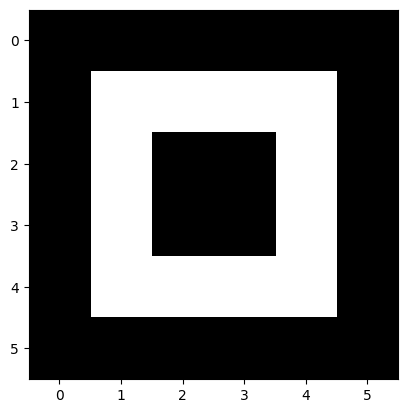

array([[  0.,   0.,   0.,   0.,   0.,   0.],
       [  0., 255., 255., 255., 255.,   0.],
       [  0., 255.,   0.,   0., 255.,   0.],
       [  0., 255.,   0.,   0., 255.,   0.],
       [  0., 255., 255., 255., 255.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.]])

In [ ]:
# Tạo một ảnh đồ chơi (toy image) 6x6 pixel để minh họa
toy_image = np.zeros((6,6))# Tạo mảng 6x6 toàn giá trị 0 (màu đen)
# Đặt giá trị 255 (trắng) cho vùng từ hàng 1-4, cột 1-4
toy_image[1:5,1:5]=255
# Đặt giá trị 0 (đen) cho vùng từ hàng 2-3, cột 2-3
toy_image[2:4,2:4]=0
plt.imshow(toy_image,cmap='gray')# Hiển thị ảnh đồ chơi
plt.show()
toy_image

We can rescale along a specific axis:

- `fx`: scale factor along the horizontal axis  
- `fy`: scale factor along the vertical axis


The parameter interpolation estimates pixel values based on neighboring pixels. <code>INTER_NEAREST</code> uses the nearest pixel and <code>INTER_CUBIC</code> uses several pixels near the pixel value we would like to estimate.


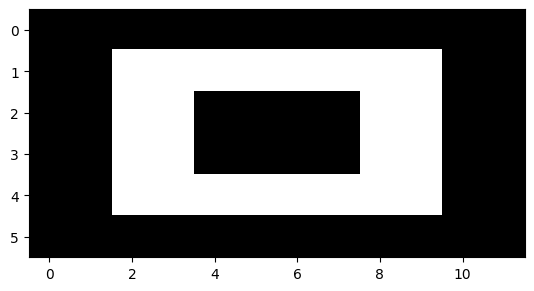

In [ ]:
# Thay đổi kích thước ảnh đồ chơi sử dụng interpolation NEAREST
# fx=2: phóng 2 lần theo chiều ngang, fy=1: giữ nguyên chiều dọc
# INTER_NEAREST: sử dụng phép nội suy nearest neighbor
new_toy = cv2.resize(toy_image,None,fx=2, fy=1, interpolation = cv2.INTER_NEAREST )
plt.imshow(new_toy,cmap='gray')
plt.show()


Consider the following image:


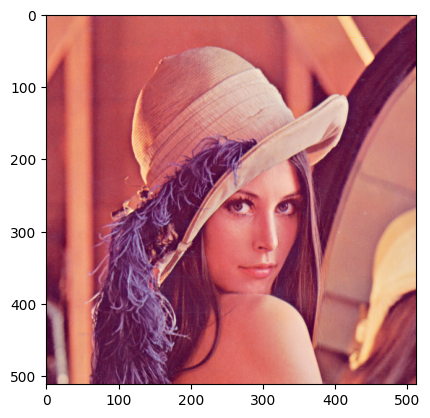

In [6]:
image = cv2.imread("lenna.png")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

We can scale the horizontal axis by two and leave the vertical axis as is:


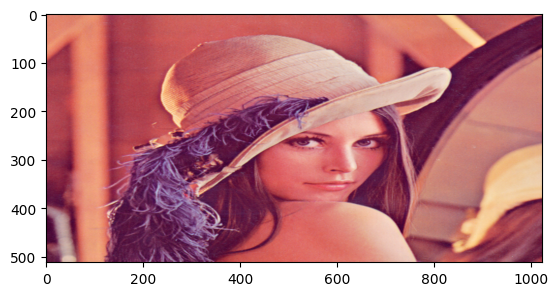

old image shape: (512, 512, 3) new image shape: (512, 1024, 3)


In [ ]:
# Thay đổi kích thước ảnh thật sử dụng interpolation CUBIC
# INTER_CUBIC: sử dụng phép nội suy bicubic (chất lượng cao hơn NEAREST)
new_image = cv2.resize(image, None, fx=2, fy=1, interpolation=cv2.INTER_CUBIC)
 # Chuyển từ BGR (OpenCV) sang RGB (matplotlib)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

In the same manner, we can scale the vertical axis by two:


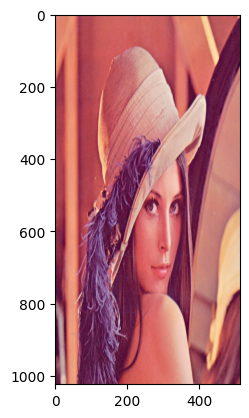

old image shape: (512, 512, 3) new image shape: (1024, 512, 3)


In [ ]:
# Phóng ảnh theo chiều dọc (fy=2, giữ nguyên chiều ngang)
new_image = cv2.resize(image, None, fx=1, fy=2, interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

We can scale the horizontal axis and vertical axis by two.


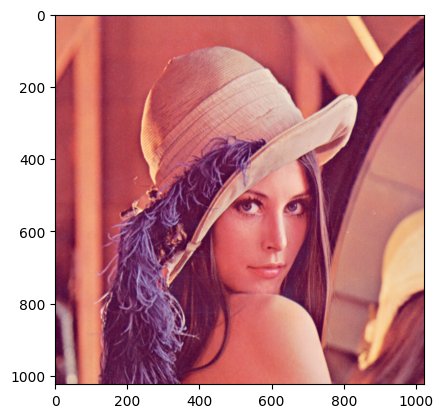

old image shape: (512, 512, 3) new image shape: (1024, 1024, 3)


In [ ]:
# Phóng đều cả 2 chiều (fx=2, fy=2)
new_image = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

We can also shrink the image by setting the scaling factor to a real number between 0 and 1:


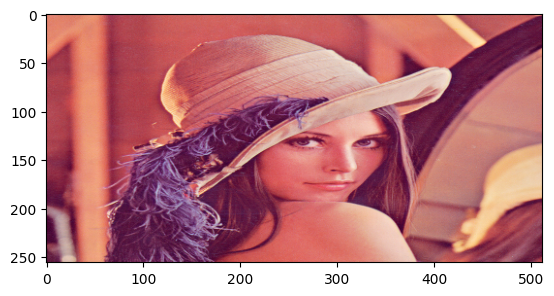

old image shape: (512, 512, 3) new image shape: (256, 512, 3)


In [ ]:
# Thu nhỏ ảnh theo chiều dọc (fy=0.5)
new_image = cv2.resize(image, None, fx=1, fy=0.5, interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

We can  also specify the number of rows and columns:


In [ ]:
# Thay đổi kích thước về kích thước cố định (100 hàng, 200 cột)
rows = 100
cols = 200

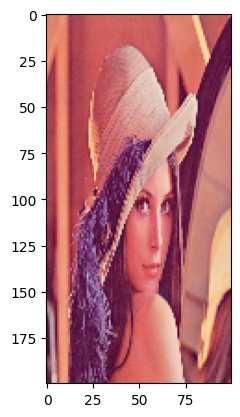

old image shape: (512, 512, 3) new image shape: (200, 100, 3)


In [12]:
new_image = cv2.resize(image, (100, 200), interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

## Translation


Translation is  when you  shift the location of the image. <code>tx</code> is the number of pixels you shift the location in the horizontal direction and <code>ty</code> is the number of pixels you shift in the vertical direction. You can create the transformation matrix $M$ to shift the image. 

In this example, we shift the image 100 pixels horizontally:


In [ ]:
# DỊCH CHUYỂN ẢNH (TRANSLATION)
tx = 100 # Dịch 100 pixel theo trục x (ngang)
ty = 0 # Không dịch theo trục y (dọc)
# Ma trận biến đổi affine cho dịch chuyển
M = np.float32([[1, 0, tx], [0, 1, ty]])
# [1, 0, tx]: giữ nguyên x, dịch tx theo trục x
# [0, 1, ty]: giữ nguyên y, dịch ty theo trục y
M # In ma trận biến đổi

array([[  1.,   0., 100.],
       [  0.,   1.,   0.]], dtype=float32)

The shape of the image is given by:


In [ ]:
# Lấy kích thước ảnh (hàng, cột, kênh màu)
rows, cols, _ = image.shape

We use the function <code>warpAffine</code> from the <code>cv2</code> module. The first input parater is an image array, the second input parameter is the transformation matrix <code>M</code>, and the final input paramter is the length and width of the output image $(cols,rows)$:


In [ ]:
# Áp dụng phép biến đổi affine
new_image = cv2.warpAffine(image, M, (cols, rows))
# warpAffine: áp dụng biến đổi affine
# (cols, rows): kích thước đầu ra

We can plot the image; the portions of the image that do not have any intensities are set to zero:


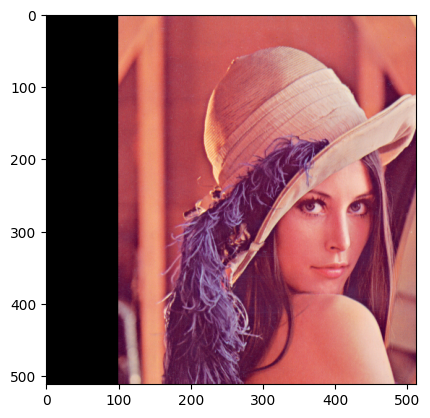

In [16]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

We can see some of the original image has been cut off. We can fix this by changing the output image size: <code>(cols + tx,rows + ty)</code>:


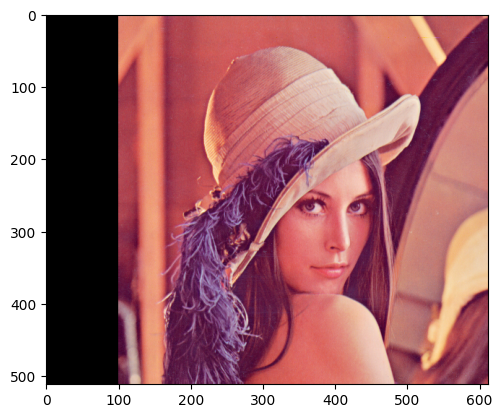

In [17]:
new_image = cv2.warpAffine(image, M, (cols + tx, rows + ty))
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

We can shift the image horizontally:


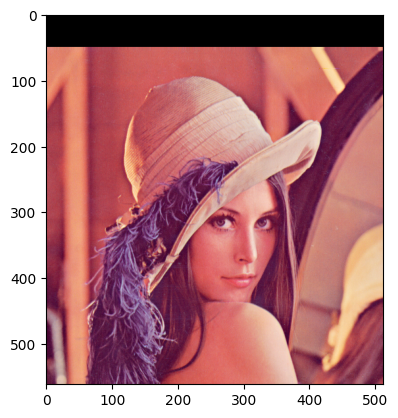

In [ ]:
# Dịch chuyển theo trục y
tx = 0  # Không dịch theo trục x
ty = 50  # Dịch 50 pixel theo trục y
M = np.float32([[1, 0, tx], [0, 1, ty]])
# Tăng kích thước đầu ra để tránh mất phần ảnh bị dịch ra ngoài
new_iamge = cv2.warpAffine(image, M, (cols + tx, rows + ty))
plt.imshow(cv2.cvtColor(new_iamge, cv2.COLOR_BGR2RGB))
plt.show()

## Rotation 


We can rotate an image by angle θ which is achieved by the Rotation Matrix <code>getRotationMatrix2D</code>.


<p><code>center</code>: Center of the rotation in the source image. We will only use the center of the image.</p>
<p><code>angle</code>: Rotation angle in degrees. Positive values mean counter-clockwise rotation (the coordinate origin is assumed to be the top-left corner).</p>
<p><code>scale</code>: Isotropic scale factor, in this course the value will be one.</p>


We can rotate our toy image by 45 degrees:


In [ ]:
# XOAY ẢNH (ROTATION)
theta = 45.0
# Tạo ma trận xoay với tâm xoay tại (3,3), góc 45 độ, tỷ lệ scale=1
M = cv2.getRotationMatrix2D(center=(3, 3), angle=theta, scale=1)
# Áp dụng xoay cho ảnh đồ chơi
new_toy_image = cv2.warpAffine(toy_image, M, (6, 6))

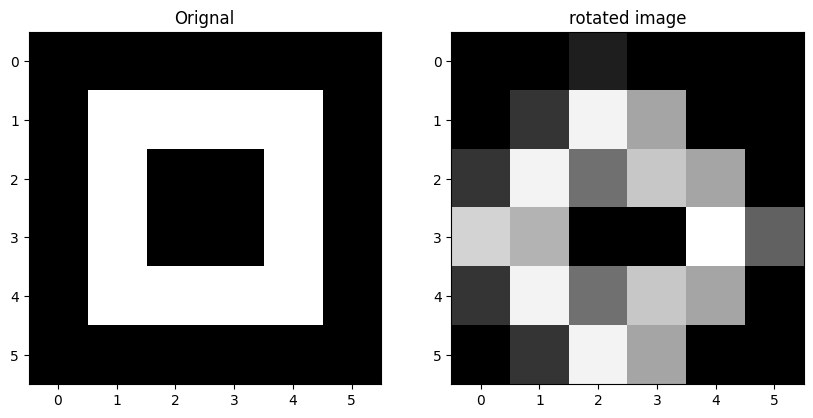

In [ ]:
# So sánh ảnh gốc và ảnh đã xoay
plot_image(toy_image, new_toy_image, title_1="Orignal", title_2="rotated image")

Looking at intensity values, we see that many values have been interpolated:


In [ ]:
# In giá trị pixel của ảnh đã xoay
new_toy_image 

array([[  0.        ,   0.        ,  28.38867188,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  47.8125    , 223.125     , 151.40625   ,
          0.        ,   0.        ],
       [ 47.8125    , 223.125     , 103.59375   , 183.28125   ,
        151.40625   ,   0.        ],
       [195.234375  , 165.10253906,   0.        ,   0.        ,
        234.82910156,  89.89746094],
       [ 47.8125    , 223.125     , 103.59375   , 183.28125   ,
        151.40625   ,   0.        ],
       [  0.        ,  47.8125    , 223.125     , 151.40625   ,
          0.        ,   0.        ]])

We can perform the same operation on color images:


In [ ]:
# Xoay ảnh thật
cols, rows, _ = image.shape

In [ ]:
# Tạo ma trận xoay với tâm ở giữa ảnh
M = cv2.getRotationMatrix2D(center=(cols // 2 - 1, rows // 2 - 1), angle=theta, scale=1)
# Áp dụng xoay
new_image = cv2.warpAffine(image, M, (cols, rows))

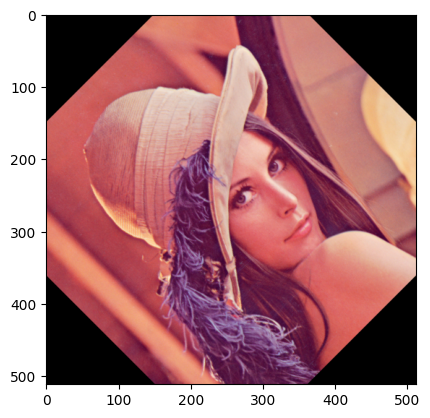

In [ ]:
# THAY ĐỔI ĐỘ SÁNG/CỘNG HẰNG SỐ
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

# Mathematical Operations 


## Array Operations 


We can perform array operations on an image; Using Python broadcasting, we can add a constant to each pixel's intensity value. 


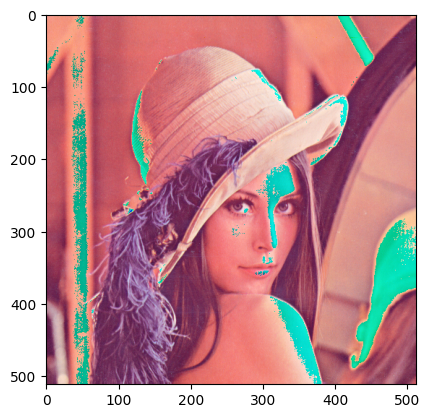

In [ ]:
# Tăng độ sáng bằng cách cộng thêm 20 vào mỗi pixel
new_image = image + 20

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

We can also multiply every pixel's intensity value by a constant value.


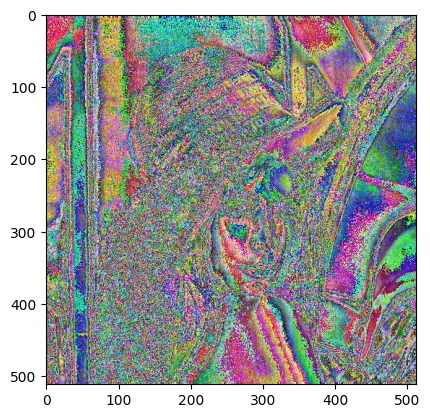

In [ ]:
# NHÂN HẰNG SỐ
new_image = 10 * image # Nhân mỗi pixel với 10 (làm sáng mạnh hơn)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

We can add the elements of two arrays of equal shape. In this example, we generate an array of random noises with the same shape and data type as our image.


In [ ]:
# THÊM NHIỄU
# Tạo nhiễu Gaussian với mean=0, std=20, kích thước bằng ảnh gốc
Noise = np.random.normal(0, 20, (rows, cols, 3)).astype(np.uint8)
Noise.shape # Kiểm tra kích thước nhiễu


(512, 512, 3)

We add the generated noise to the image and plot the result. We see the values that have corrupted the image:


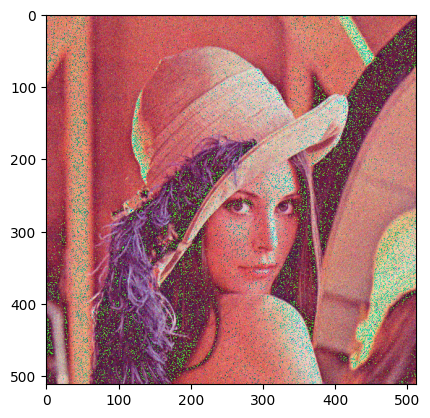

In [ ]:
 # Cộng nhiễu vào ảnh
new_image = image + Noise
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

At the same time, we can multiply the elements of two arrays of equal shape. We can multiply the random image and the Lenna image and plot the result. 


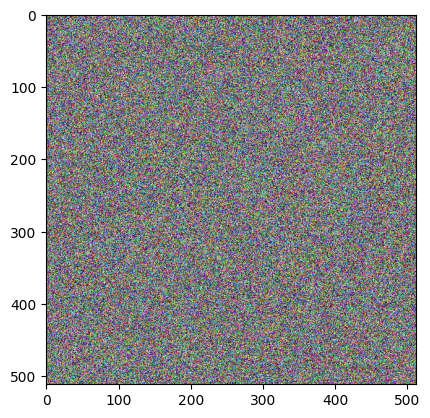

In [ ]:
# NHÂN VỚI NHIỄU
new_image = image*Noise

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

## Matrix Operations 


Grayscale images are matrices. Consider the following grayscale image:


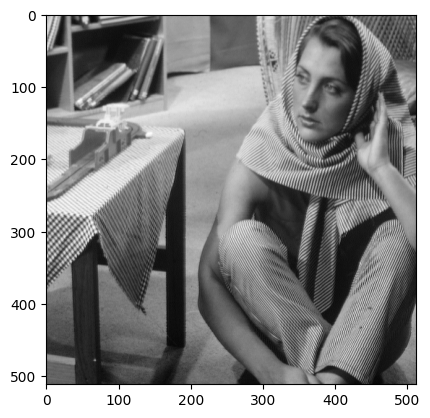

In [ ]:
# PHÂN TÍCH SVD (SINGULAR VALUE DECOMPOSITION)
# Đọc ảnh barbara ở chế độ grayscale
im_gray = cv2.imread('barbara.png', cv2.IMREAD_GRAYSCALE)
im_gray.shape # Kiểm tra kích thước ảnh xám

plt.imshow(im_gray,cmap='gray')
plt.show()

We can apply algorithms designed for matrices.  We can use  Singular Value Decomposition, decomposing our image matrix into  a product of three matrices.


In [ ]:
# Phân tích SVD: A = U * S * V^T
U, s, V = np.linalg.svd(im_gray , full_matrices=True)
# U: ma trận singular vectors trái
# s: mảng các singular values (giá trị suy biến)
# V: ma trận singular vectors phải (V^T là chuyển vị)

We see <code>s</code> is not rectangular:


In [ ]:
s.shape # Kiểm tra kích thước mảng singular values

(512,)

We can convert  <code>s</code> to a diagonal matrix <code>S</code>:


In [ ]:
# Tạo ma trận đường chéo S từ mảng s
S = np.zeros((im_gray.shape[0], im_gray.shape[1]))
S[:image.shape[0], :image.shape[0]] = np.diag(s)


We can plot the matrix `U` and `V`:


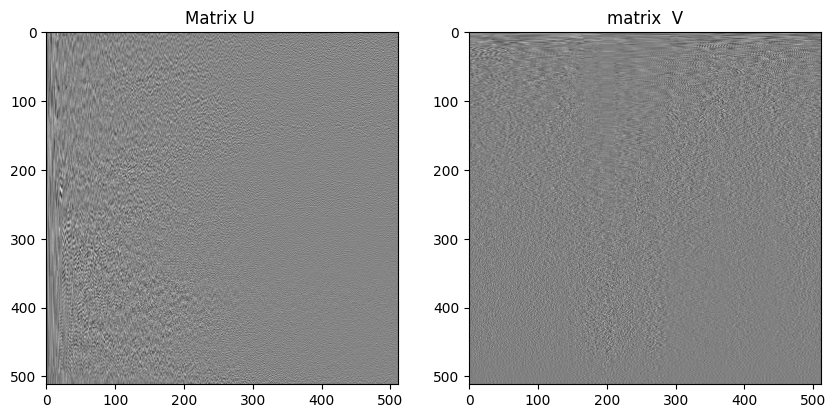

In [ ]:
# Vẽ ma trận U và V (có lỗi trong code gốc, plot_image cần 2 ảnh)
# plot_image(U, V, title_1="Matrix U ", title_2="matrix V")  # Dòng này bị lỗi

plot_image(U,V,title_1="Matrix U ",title_2="matrix  V")

We see most of the elements in `S` are zero:


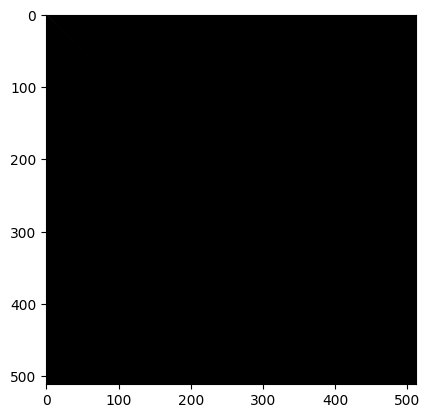

In [ ]:
 # Hiển thị ma trận S
plt.imshow(S,cmap='gray')
plt.show()

We can find the matrix product of all the matrices. First, we can perform matrix multiplication on `S` and `U` and assign it  to `B` and plot the results: 


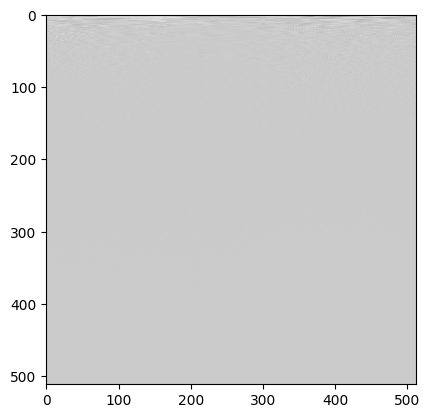

In [ ]:
# Tái tạo ảnh từ các thành phần SVD
# Nhân S với V
B = S.dot(V)
plt.imshow(B,cmap='gray')
plt.show()

We can find the matrix product of `U`, `S`, and `B`. We see it’s the entire image:


In [ ]:
# Nhân U với B để tái tạo ảnh gốc
A = U.dot(B)

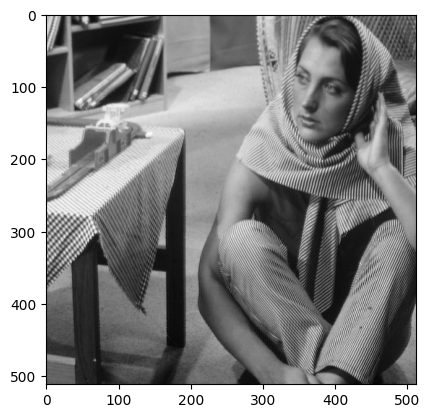

In [38]:
plt.imshow(A,cmap='gray')
plt.show()

It turns out many elements are redundant, so we can eliminate some rows and columns of `S` and `V` and approximate the image by finding the product.


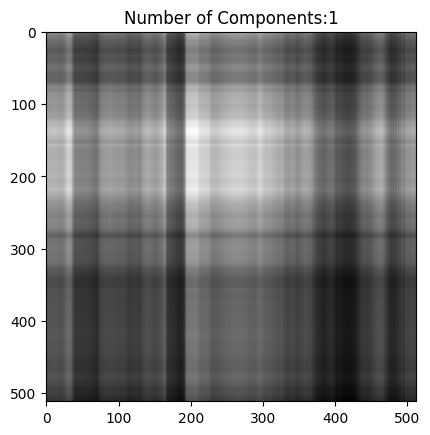

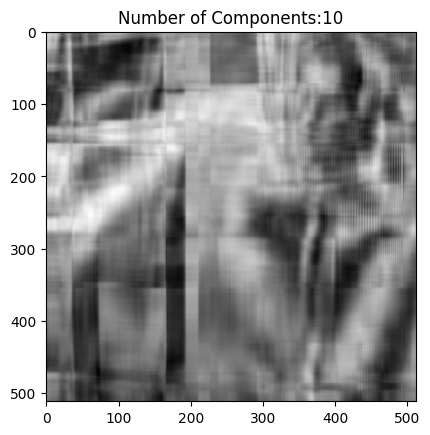

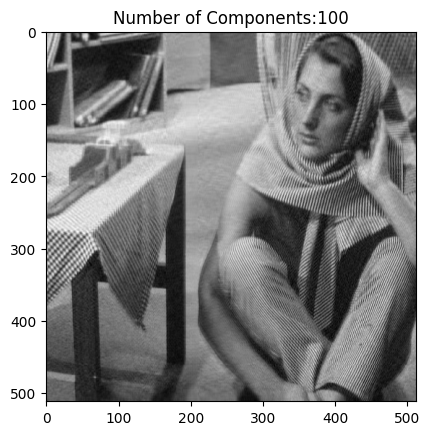

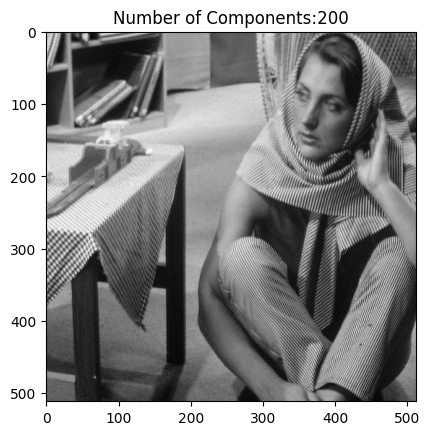

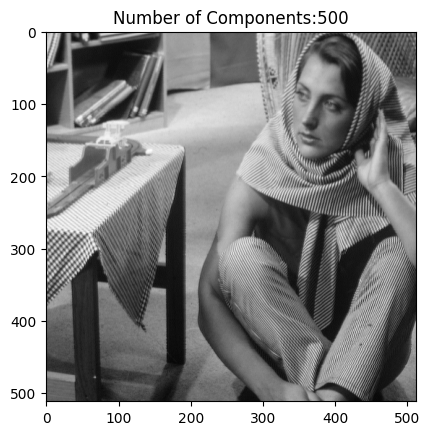

In [ ]:
# THỬ NÉN ẢNH BẰNG SVD - chỉ giữ lại một số thành phần chính
# Số lượng singular values giữ lại
for n_component in [1,10,100,200, 500]:
    # Chỉ giữ n_component cột đầu của S
    S_new = S[:, :n_component]
    # Chỉ giữ n_component hàng đầu của V
    V_new = V[:n_component, :]
     # Tái tạo ảnh với số thành phần giới hạn
    A = U.dot(S_new.dot(V_new))
    plt.imshow(A,cmap='gray')
    plt.title("Number of Components:"+str(n_component))
    plt.show()

We see we only need 100 to 200 Components to represent the image.


# References 


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<!--<h2>Change Log</h2>-->


<!--
<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2020-07-20</td>
        <td>0.2</td>
        <td>Azim</td>
        <td>Modified Multiple Areas</td>
    </tr>
    <tr>
        <td>2020-07-17</td>
        <td>0.1</td>
        <td>Azim</td>
        <td>Created Lab Template</td>
    </tr>
</table>
-->



<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
